# Logistic Regression in Python

**Topic:** Logistic Regression for binary classification  
**Focus:** practical machine learning workflow, probability interpretation, threshold tuning, and business-oriented model evaluation.

This notebook follows a standard analytics workflow: understand the business problem, inspect the data, clean and prepare it, build a logistic regression model, evaluate it, and interpret the result in decision terms.

## 1. Setup

The notebook uses common Python analytics libraries. The code is intentionally written in a readable style so that each step can be inspected and adapted.

In [22]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical / machine learning libraries
from scipy.special import expit
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.inspection import DecisionBoundaryDisplay

# Optional: statsmodels gives a statistical coefficient table.
import statsmodels.api as sm

RANDOM_STATE = 42
DATA_DIR = Path("data")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 2. Helper functions

These small helper functions keep repeated evaluation steps compact. The model building itself remains explicit.

In [2]:
def summarize_missing_values(df):
    """Return missing-value counts and percentages by column."""
    summary = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100
    }).sort_values("missing_percent", ascending=False)
    return summary


def plot_confusion_matrix(y_true, y_pred, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Class 0", "Class 1"]
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


def evaluate_binary_classifier(y_true, y_pred, y_proba=None, label="Model"):
    """Print the most important binary-classification metrics."""
    metrics = {
        "model": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
    return pd.DataFrame([metrics])


def predict_with_threshold(probabilities, threshold=0.5):
    """Convert probabilities into class labels using a custom threshold."""
    return (probabilities >= threshold).astype(int)

## 3. Simple example: why logistic regression is needed

A linear model can produce values below 0 or above 1. For classification, this is not appropriate because probabilities must stay between 0 and 1. Logistic regression solves this by applying the sigmoid function to a linear score.

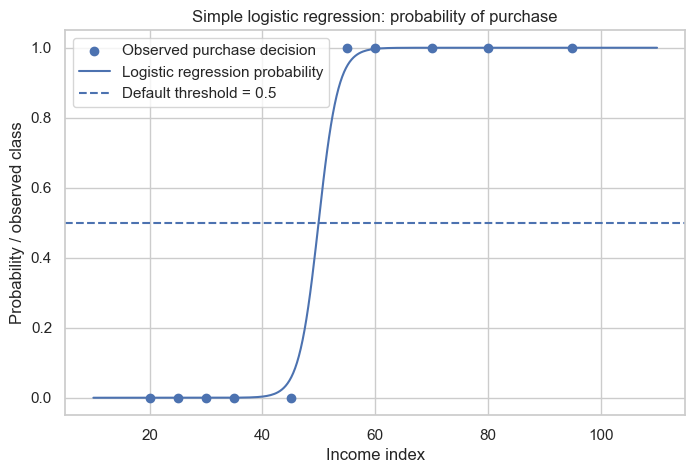

In [3]:
# A simple income vs purchase example
income = np.array([20, 25, 30, 35, 45, 55, 60, 70, 80, 95]).reshape(-1, 1)
purchased = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

simple_model = LogisticRegression()
simple_model.fit(income, purchased)

income_grid = np.linspace(10, 110, 300).reshape(-1, 1)
purchase_probability = simple_model.predict_proba(income_grid)[:, 1]

plt.figure(figsize=(8, 5))
plt.scatter(income, purchased, label="Observed purchase decision")
plt.plot(income_grid, purchase_probability, label="Logistic regression probability")
plt.axhline(0.5, linestyle="--", label="Default threshold = 0.5")
plt.title("Simple logistic regression: probability of purchase")
plt.xlabel("Income index")
plt.ylabel("Probability / observed class")
plt.legend()
plt.show()

**Interpretation.** The model does not directly output only “yes” or “no”. It first estimates a probability. A threshold then converts the probability into a class decision. The default threshold is usually 0.5, but it can be changed when the business cost of mistakes is asymmetric.

## 4. Logistic regression mechanics in one visual

The model first calculates a linear score and then transforms it with the sigmoid function. Large negative scores become probabilities close to 0; large positive scores become probabilities close to 1.

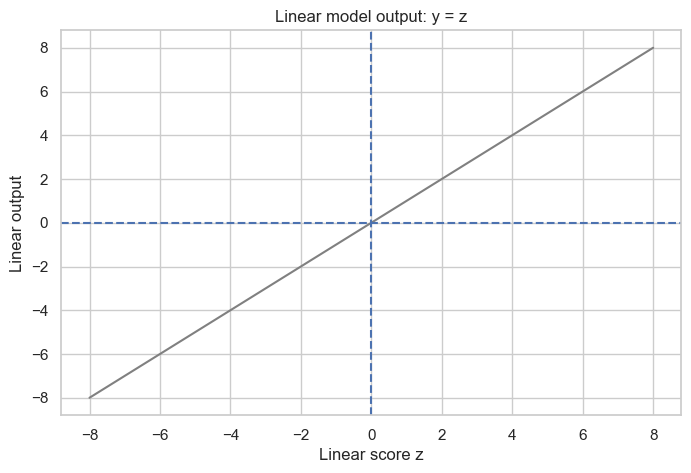

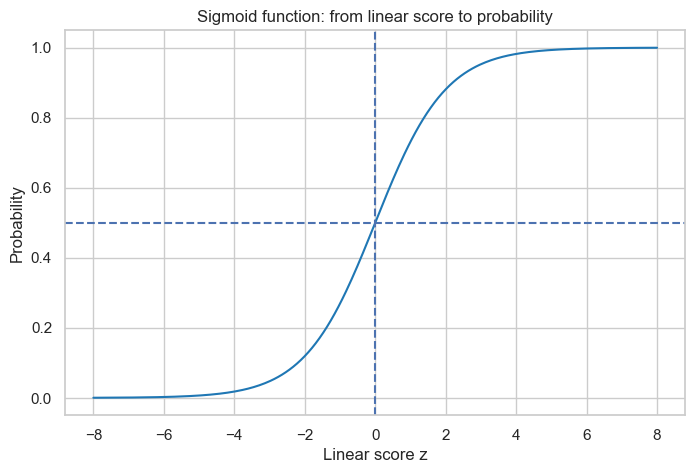

In [4]:
z = np.linspace(-8, 8, 300)
linear_output = z
prob = expit(z)

# 1) Linear output (unbounded)
plt.figure(figsize=(8, 5))
plt.plot(z, linear_output, color="gray")
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.title("Linear model output: y = z")
plt.xlabel("Linear score z")
plt.ylabel("Linear output")
plt.show()

# 2) Sigmoid-transformed output (bounded to [0, 1])
plt.figure(figsize=(8, 5))
plt.plot(z, prob, color="tab:blue")
plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")
plt.title("Sigmoid function: from linear score to probability")
plt.xlabel("Linear score z")
plt.ylabel("Probability")
plt.show()

## 5. Built-in dataset example: breast cancer classification

This first realistic example uses a clean built-in dataset. The workflow checks data quality, missing values, class balance, scaling, model fitting, and evaluation.

In [5]:
# Load a built-in binary-classification dataset
breast = load_breast_cancer(as_frame=True)
breast_df = breast.frame.copy()

# In this dataset, target 0 = malignant and target 1 = benign.
# For easier interpretation, create a target where 1 = malignant risk.
breast_df["malignant"] = (breast_df["target"] == 0).astype(int)
breast_df = breast_df.drop(columns="target")

print("Shape:", breast_df.shape)
breast_df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.990,10.380,122.800,"1,001.000",0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,"2,019.000",0.162,0.666,0.712,0.265,0.460,0.119,1
1,20.570,17.770,132.900,"1,326.000",0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,"1,956.000",0.124,0.187,0.242,0.186,0.275,0.089,1
2,19.690,21.250,130.000,"1,203.000",0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,"1,709.000",0.144,0.424,0.450,0.243,0.361,0.088,1
3,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173,1
4,20.290,14.340,135.100,"1,297.000",0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,"1,575.000",0.137,0.205,0.400,0.163,0.236,0.077,1


In [6]:
# Data quality check: missing values
missing_breast = summarize_missing_values(breast_df)
missing_breast.head(10)

,missing_count,missing_percent
mean radius,0,0.000
mean texture,0,0.000
mean perimeter,0,0.000
mean area,0,0.000
mean smoothness,0,0.000
mean compactness,0,0.000
mean concavity,0,0.000
mean concave points,0,0.000
mean symmetry,0,0.000
mean fractal dimension,0,0.000


Even when a dataset is known to be clean, the workflow explicitly checks for missing values. If no missing values are found, document it and continue. This prevents silent assumptions.

Data Cleaning: 
* LinkedIn: https://www.linkedin.com/learning/data-cleaning-in-python-essential-training-17061364/missing-values?resume=false
* DataCamp: https://www.datacamp.com/courses/cleaning-data-in-python

In [7]:
# Target balance
class_balance = breast_df["malignant"].value_counts(normalize=True).rename("share").to_frame()
class_balance["count"] = breast_df["malignant"].value_counts()
class_balance

,share,count
malignant,,
0,0.627,357
1,0.373,212


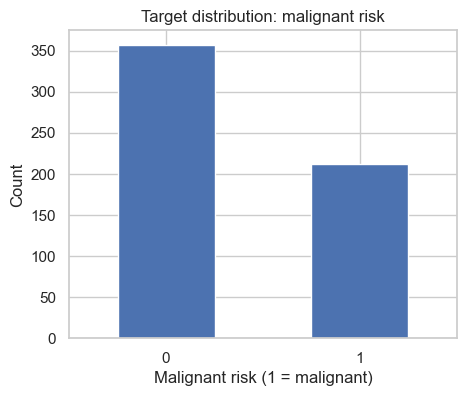

In [8]:
plt.figure(figsize=(5, 4))
breast_df["malignant"].value_counts().sort_index().plot(kind="bar")
plt.title("Target distribution: malignant risk")
plt.xlabel("Malignant risk (1 = malignant)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [9]:
# Train/test split before preprocessing to avoid leakage
X = breast_df.drop(columns="malignant")
y = breast_df["malignant"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (426, 30)
Test shape: (143, 30)


In [11]:
# Numeric preprocessing: median imputation is included for completeness, even though no missing values were found.
numeric_features = X_train.columns.tolist()

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

breast_model = Pipeline(steps=[
    ("preprocess", numeric_preprocess),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

breast_model.fit(X_train, y_train)

breast_proba = breast_model.predict_proba(X_test)[:, 1]
breast_pred_default = predict_with_threshold(breast_proba, threshold=0.5)

evaluate_binary_classifier(y_test, breast_pred_default, breast_proba, label="Breast cancer logistic regression")

,model,accuracy,precision,recall,f1,roc_auc
0,Breast cancer logistic regression,0.965,0.980,0.925,0.951,0.996


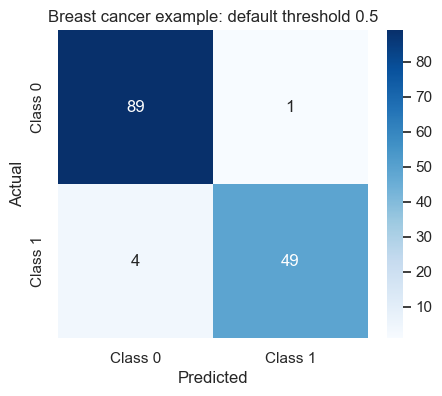

               precision    recall  f1-score   support

not malignant       0.96      0.99      0.97        90
    malignant       0.98      0.92      0.95        53

     accuracy                           0.97       143
    macro avg       0.97      0.96      0.96       143
 weighted avg       0.97      0.97      0.96       143



In [12]:
plot_confusion_matrix(y_test, breast_pred_default, "Breast cancer example: default threshold 0.5")
print(classification_report(y_test, breast_pred_default, target_names=["not malignant", "malignant"]))

**Interpretation.** Accuracy is useful as a first check, but recall and precision explain the quality of positive-class detection. In risk-oriented settings, the positive class should be defined carefully before reading the confusion matrix.

## 6. Threshold tuning: probability is not the same as decision

The logistic regression model outputs probabilities. The threshold translates probabilities into decisions. Lower thresholds usually increase recall but also create more false positives. Higher thresholds usually increase precision but can miss more true positives.

In [13]:
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = predict_with_threshold(breast_proba, threshold)
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.head()

,threshold,accuracy,precision,recall,f1
0,0.100,0.951,0.897,0.981,0.937
1,0.150,0.965,0.929,0.981,0.954
2,0.200,0.965,0.944,0.962,0.953
3,0.250,0.972,0.962,0.962,0.962
4,0.300,0.979,0.981,0.962,0.971


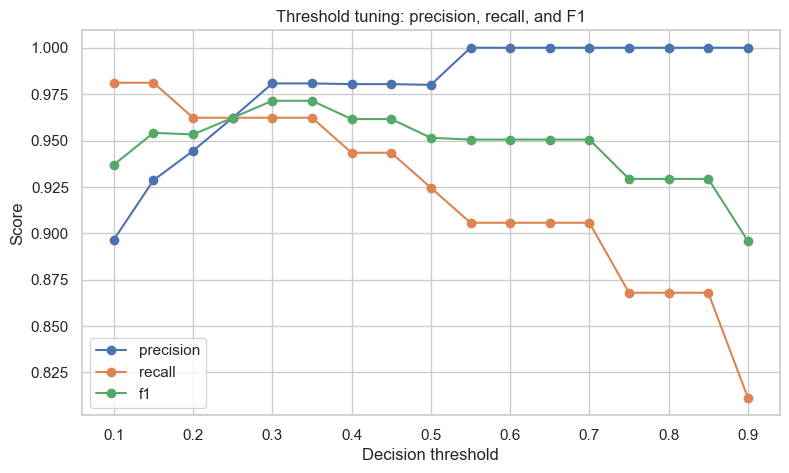

In [14]:
plt.figure(figsize=(9, 5))
for metric in ["precision", "recall", "f1"]:
    plt.plot(threshold_df["threshold"], threshold_df[metric], marker="o", label=metric)
plt.title("Threshold tuning: precision, recall, and F1")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [15]:
# Example: choose the threshold with the highest F1 score
best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_threshold = best_f1_row["threshold"]

best_f1_row.to_frame().T

,threshold,accuracy,precision,recall,f1
4,0.300,0.979,0.981,0.962,0.971


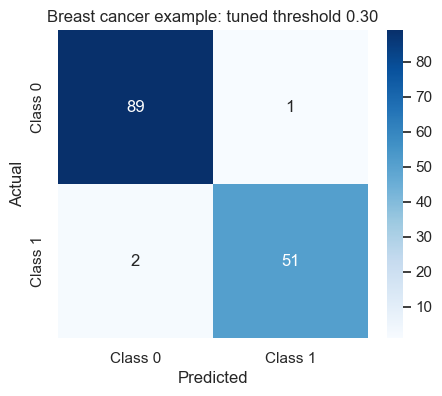

,model,accuracy,precision,recall,f1,roc_auc
0,Threshold 0.30,0.979,0.981,0.962,0.971,0.996


In [16]:
breast_pred_best = predict_with_threshold(breast_proba, best_threshold)
plot_confusion_matrix(y_test, breast_pred_best, f"Breast cancer example: tuned threshold {best_threshold:.2f}")
evaluate_binary_classifier(y_test, breast_pred_best, breast_proba, label=f"Threshold {best_threshold:.2f}")

## 7. ROC curve and probability quality

The ROC curve summarizes how well the model separates the two classes across many thresholds. AUC close to 0.5 means weak separation; values closer to 1 indicate stronger separation.

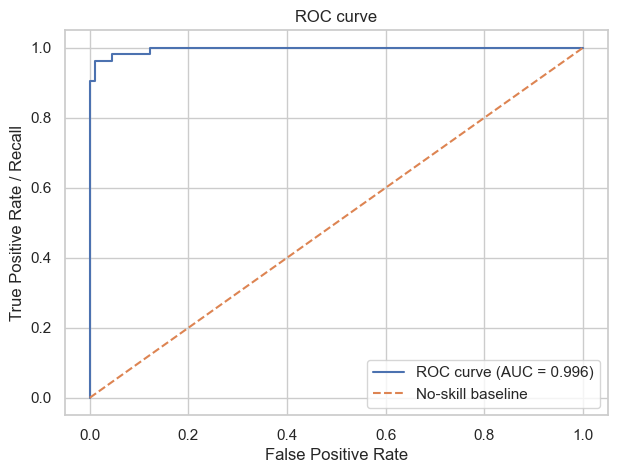

In [17]:
fpr, tpr, roc_thresholds = roc_curve(y_test, breast_proba)
auc_value = roc_auc_score(y_test, breast_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="No-skill baseline")
plt.title("ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend()
plt.show()

## 8. Coefficient interpretation

Logistic regression is valued because it is relatively interpretable. Coefficients indicate the direction of association after preprocessing. Positive coefficients increase the log-odds of class 1; negative coefficients decrease them.

Because the features are standardized in this example, coefficients are more comparable than they would be on raw scales.

In [18]:
# Extract coefficients from the fitted pipeline
coef_table = pd.DataFrame({
    "feature": numeric_features,
    "coefficient": breast_model.named_steps["model"].coef_[0]
})
coef_table["abs_coefficient"] = coef_table["coefficient"].abs()
coef_table = coef_table.sort_values("abs_coefficient", ascending=False)
coef_table.head(15)

,feature,coefficient,abs_coefficient
21,worst texture,1.366,1.366
10,radius error,1.267,1.267
28,worst symmetry,1.036,1.036
7,mean concave points,0.963,0.963
15,compactness error,-0.927,0.927
23,worst area,0.889,0.889
20,worst radius,0.887,0.887
13,area error,0.878,0.878
6,mean concavity,0.874,0.874
26,worst concavity,0.868,0.868


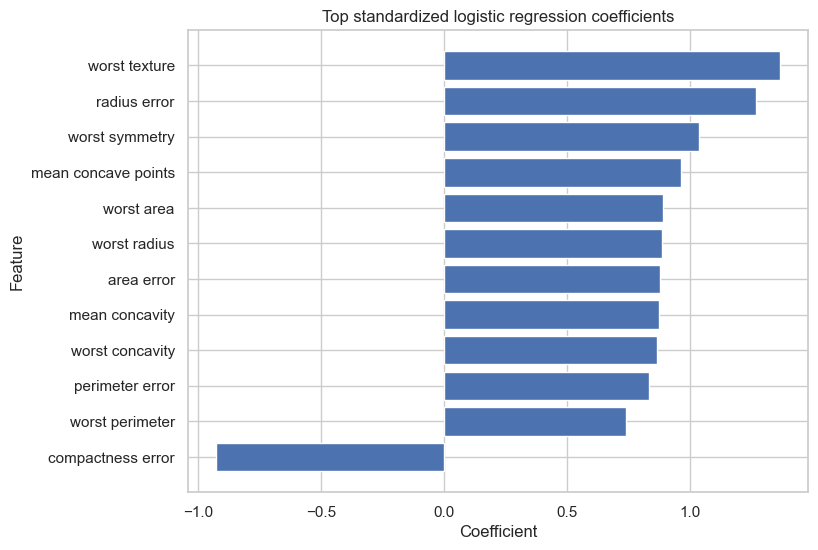

In [19]:
plt.figure(figsize=(8, 6))
top_coef = coef_table.head(12).sort_values("coefficient")
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.title("Top standardized logistic regression coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

**Interpretation note.** Coefficients are not automatically causal effects. They describe how the fitted model uses the feature, conditional on the other features and preprocessing choices.

# 10. Telecom churn example

This example uses the provided training and test CSV files. The business goal is to estimate which customers are likely to churn so that retention actions can be prioritized.

In [23]:
telco_train_path = DATA_DIR / "telco_churn_train.csv"
telco_test_path = DATA_DIR / "telco_churn_test.csv"

if not telco_train_path.exists() or not telco_test_path.exists():
    raise FileNotFoundError("Expected telco_churn_train.csv and telco_churn_test.csv in /mnt/data")

telco_train = pd.read_csv(telco_train_path)
telco_test = pd.read_csv(telco_test_path)

print("Train shape:", telco_train.shape)
print("Test shape:", telco_test.shape)
telco_train.head()

Train shape: (1000, 16)
Test shape: (4, 15)


,churn,address,callcard,cardmon,custcat,ebill,ed,employ,equip,gender,income,marital,region,tenure,voice,wireless
0,1.000,9.000,1.000,7.500,1.000,0.000,4.000,5.000,0.000,0.000,64.000,1.000,2.000,13.000,0.000,0.000
1,1.000,7.000,1.000,15.250,4.000,0.000,5.000,5.000,0.000,0.000,136.000,1.000,NaN,11.000,1.000,1.000
2,0.000,24.000,1.000,30.250,3.000,0.000,1.000,29.000,0.000,1.000,116.000,1.000,3.000,68.000,0.000,0.000
3,1.000,12.000,0.000,0.000,1.000,0.000,2.000,0.000,0.000,1.000,33.000,0.000,3.000,33.000,0.000,0.000
4,0.000,9.000,0.000,0.000,3.000,0.000,1.000,2.000,0.000,0.000,30.000,1.000,3.000,23.000,0.000,0.000


## 10.1 Data understanding and quality checks

The workflow checks structure, target distribution, duplicates, missing values, and basic numeric ranges before modeling.

In [24]:
display(telco_train.info())

display(telco_train.describe().T)

print("Duplicate rows in training data:", telco_train.duplicated().sum())
print("Duplicate rows in test data:", telco_test.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   churn     1000 non-null   float64
 1   address   1000 non-null   float64
 2   callcard  1000 non-null   float64
 3   cardmon   1000 non-null   float64
 4   custcat   1000 non-null   float64
 5   ebill     1000 non-null   float64
 6   ed        1000 non-null   float64
 7   employ    1000 non-null   float64
 8   equip     1000 non-null   float64
 9   gender    1000 non-null   float64
 10  income    1000 non-null   float64
 11  marital   1000 non-null   float64
 12  region    619 non-null    float64
 13  tenure    1000 non-null   float64
 14  voice     1000 non-null   float64
 15  wireless  1000 non-null   float64
dtypes: float64(16)
memory usage: 125.1 KB


None

,count,mean,std,min,25%,50%,75%,max
churn,"1,000.000",0.274,0.446,0.000,0.000,0.000,1.000,1.000
address,"1,000.000",11.551,10.087,0.000,3.000,9.000,18.000,55.000
callcard,"1,000.000",0.678,0.467,0.000,0.000,1.000,1.000,1.000
cardmon,"1,000.000",13.781,14.084,0.000,0.000,12.000,20.500,109.250
custcat,"1,000.000",2.487,1.120,1.000,1.000,3.000,3.000,4.000
ebill,"1,000.000",0.371,0.483,0.000,0.000,0.000,1.000,1.000
ed,"1,000.000",2.671,1.222,1.000,2.000,3.000,4.000,5.000
employ,"1,000.000",10.987,10.082,0.000,3.000,8.000,17.000,47.000
equip,"1,000.000",0.386,0.487,0.000,0.000,0.000,1.000,1.000
gender,"1,000.000",0.517,0.500,0.000,0.000,1.000,1.000,1.000


Duplicate rows in training data: 0
Duplicate rows in test data: 0


In [25]:
missing_telco_train = summarize_missing_values(telco_train)
missing_telco_test = summarize_missing_values(telco_test)

print("Training missing values:")
display(missing_telco_train.head(10))

print("Test missing values:")
display(missing_telco_test.head(10))

Training missing values:


,missing_count,missing_percent
region,381,38.100
churn,0,0.000
callcard,0,0.000
address,0,0.000
custcat,0,0.000
ebill,0,0.000
ed,0,0.000
cardmon,0,0.000
employ,0,0.000
equip,0,0.000


Test missing values:


,missing_count,missing_percent
region,2,50.000
callcard,0,0.000
address,0,0.000
custcat,0,0.000
ebill,0,0.000
ed,0,0.000
cardmon,0,0.000
employ,0,0.000
equip,0,0.000
income,0,0.000


**Interpretation.** The region column contains missing values, so the preprocessing pipeline will impute it. If a different dataset version has no missing values, the same code still runs and simply moves to the next step.

In [26]:
# Target balance
churn_balance = telco_train["churn"].value_counts(normalize=True).rename("share").to_frame()
churn_balance["count"] = telco_train["churn"].value_counts()
churn_balance

,share,count
churn,,
0.000,0.726,726
1.000,0.274,274


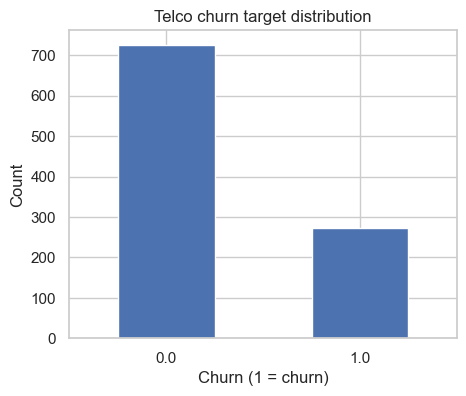

In [27]:
plt.figure(figsize=(5, 4))
telco_train["churn"].value_counts().sort_index().plot(kind="bar")
plt.title("Telco churn target distribution")
plt.xlabel("Churn (1 = churn)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

<Figure size 700x500 with 0 Axes>

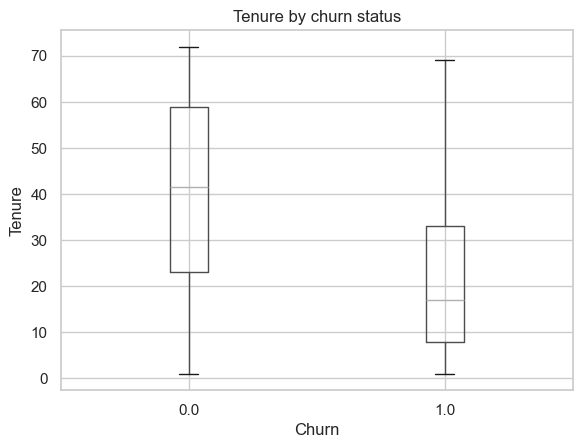

<Figure size 700x500 with 0 Axes>

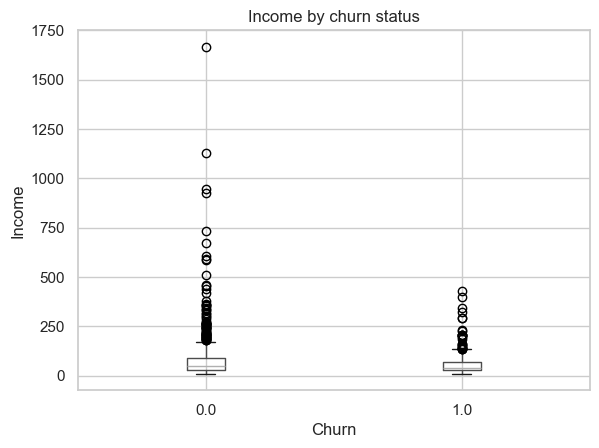

In [28]:
# Basic numeric relationships
plt.figure(figsize=(7, 5))
telco_train.boxplot(column="tenure", by="churn")
plt.title("Tenure by churn status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

plt.figure(figsize=(7, 5))
telco_train.boxplot(column="income", by="churn")
plt.title("Income by churn status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Income")
plt.show()

## 10.2 Data preparation

Logistic regression is sensitive to feature scale, so numeric features are standardized. Missing numeric values are imputed with the median. The test set does not contain the target, so it is used only for final churn scoring.

In [29]:
# Separate features and target
X_telco = telco_train.drop(columns="churn")
y_telco = telco_train["churn"].astype(int)

X_telco_train, X_telco_valid, y_telco_train, y_telco_valid = train_test_split(
    X_telco, y_telco,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_telco
)

print("Training target balance:")
print(y_telco_train.value_counts(normalize=True))
print("\nValidation target balance:")
print(y_telco_valid.value_counts(normalize=True))

Training target balance:
churn
0   0.725
1   0.275
Name: proportion, dtype: float64

Validation target balance:
churn
0   0.728
1   0.272
Name: proportion, dtype: float64


In [27]:
# In this dataset all features are numeric-coded.
telco_numeric_features = X_telco_train.columns.tolist()

telco_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

telco_logreg = Pipeline(steps=[
    ("preprocess", telco_preprocess),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

telco_logreg.fit(X_telco_train, y_telco_train)

telco_valid_proba = telco_logreg.predict_proba(X_telco_valid)[:, 1]
telco_valid_pred = predict_with_threshold(telco_valid_proba, threshold=0.5)

evaluate_binary_classifier(y_telco_valid, telco_valid_pred, telco_valid_proba, label="Telco logistic regression")

,model,accuracy,precision,recall,f1,roc_auc
0,Telco logistic regression,0.760,0.580,0.426,0.492,0.780


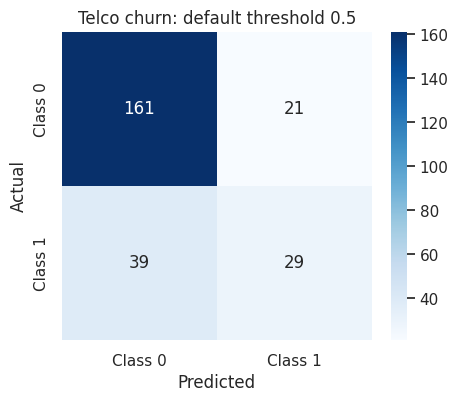

              precision    recall  f1-score   support

      retain       0.81      0.88      0.84       182
       churn       0.58      0.43      0.49        68

    accuracy                           0.76       250
   macro avg       0.69      0.66      0.67       250
weighted avg       0.74      0.76      0.75       250



In [28]:
plot_confusion_matrix(y_telco_valid, telco_valid_pred, "Telco churn: default threshold 0.5")
print(classification_report(y_telco_valid, telco_valid_pred, target_names=["retain", "churn"]))

## 10.3 Handling imbalance with class weights

When churn is the minority class, a model can look acceptable while missing too many churners. One simple algorithm-level correction is `class_weight="balanced"`, which penalizes errors on the minority class more strongly.

In [29]:
telco_logreg_balanced = Pipeline(steps=[
    ("preprocess", telco_preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

telco_logreg_balanced.fit(X_telco_train, y_telco_train)

telco_balanced_proba = telco_logreg_balanced.predict_proba(X_telco_valid)[:, 1]
telco_balanced_pred = predict_with_threshold(telco_balanced_proba, threshold=0.5)

comparison = pd.concat([
    evaluate_binary_classifier(y_telco_valid, telco_valid_pred, telco_valid_proba, label="Standard"),
    evaluate_binary_classifier(y_telco_valid, telco_balanced_pred, telco_balanced_proba, label="Class-weight balanced")
])
comparison

,model,accuracy,precision,recall,f1,roc_auc
0,Standard,0.760,0.580,0.426,0.492,0.780
0,Class-weight balanced,0.724,0.495,0.691,0.577,0.778


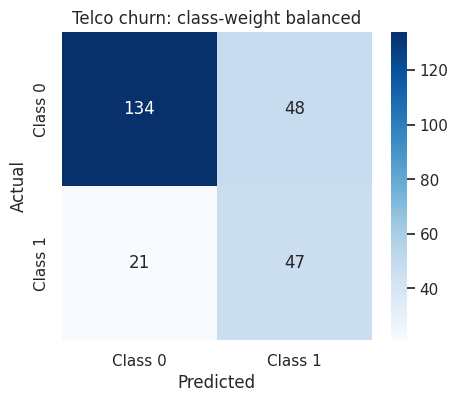

In [30]:
plot_confusion_matrix(y_telco_valid, telco_balanced_pred, "Telco churn: class-weight balanced")

**Interpretation.** Class weighting often increases recall for the churn class, but it may reduce precision. In business terms, the model may catch more at-risk customers while also contacting more customers who would not have churned.

## 10.4 Threshold tuning for churn campaigns

For churn management, the threshold is a business decision. A lower threshold means more customers are flagged for retention campaigns. This can be useful if the campaign is cheap and missing churners is costly.

In [31]:
telco_threshold_results = []
for threshold in thresholds:
    pred = predict_with_threshold(telco_balanced_proba, threshold)
    telco_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_telco_valid, pred),
        "precision": precision_score(y_telco_valid, pred, zero_division=0),
        "recall": recall_score(y_telco_valid, pred, zero_division=0),
        "f1": f1_score(y_telco_valid, pred, zero_division=0),
        "flagged_share": pred.mean()
    })

telco_threshold_df = pd.DataFrame(telco_threshold_results)
telco_threshold_df.head()

,threshold,accuracy,precision,recall,f1,flagged_share
0,0.100,0.416,0.314,0.971,0.475,0.840
1,0.150,0.480,0.337,0.941,0.496,0.760
2,0.200,0.544,0.366,0.926,0.525,0.688
3,0.250,0.588,0.389,0.897,0.542,0.628
4,0.300,0.632,0.418,0.897,0.570,0.584


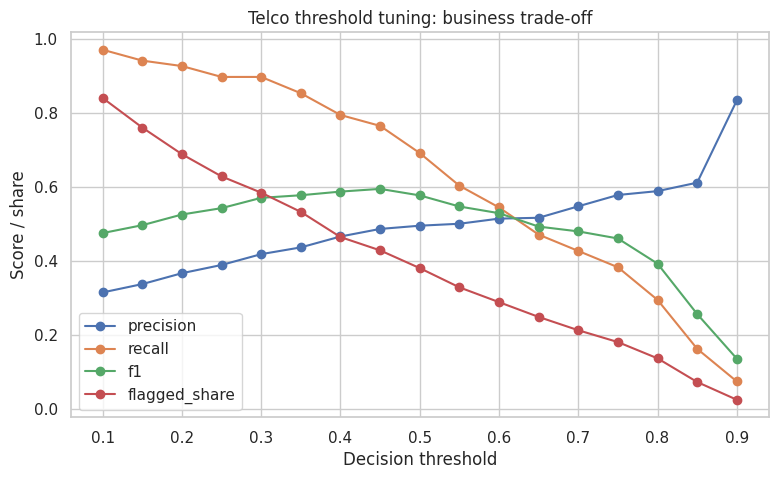

In [32]:
plt.figure(figsize=(9, 5))
for metric in ["precision", "recall", "f1", "flagged_share"]:
    plt.plot(telco_threshold_df["threshold"], telco_threshold_df[metric], marker="o", label=metric)
plt.title("Telco threshold tuning: business trade-off")
plt.xlabel("Decision threshold")
plt.ylabel("Score / share")
plt.legend()
plt.show()

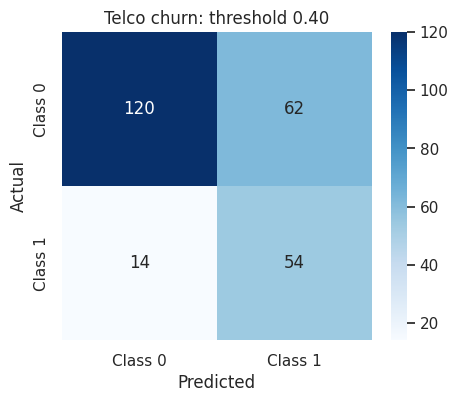

,model,accuracy,precision,recall,f1,roc_auc
0,Telco threshold 0.40,0.696,0.466,0.794,0.587,0.778


In [33]:
# Select a practical example threshold that aims for stronger recall.
# This is not universally optimal; it depends on campaign cost and retention value.
churn_threshold = 0.40

telco_campaign_pred = predict_with_threshold(telco_balanced_proba, churn_threshold)
plot_confusion_matrix(y_telco_valid, telco_campaign_pred, f"Telco churn: threshold {churn_threshold:.2f}")
evaluate_binary_classifier(y_telco_valid, telco_campaign_pred, telco_balanced_proba, label=f"Telco threshold {churn_threshold:.2f}")

## 10.5 Feature interpretation for telco churn

Because features are scaled, larger absolute coefficients indicate stronger influence in the fitted model. Positive coefficients push the prediction toward churn; negative coefficients push it toward retention.

In [34]:
telco_coef = pd.DataFrame({
    "feature": telco_numeric_features,
    "coefficient": telco_logreg_balanced.named_steps["model"].coef_[0]
})
telco_coef["abs_coefficient"] = telco_coef["coefficient"].abs()
telco_coef = telco_coef.sort_values("abs_coefficient", ascending=False)
telco_coef

,feature,coefficient,abs_coefficient
12,tenure,-0.721,0.721
1,callcard,-0.531,0.531
7,equip,0.442,0.442
6,employ,-0.426,0.426
13,voice,0.182,0.182
2,cardmon,0.172,0.172
4,ebill,0.163,0.163
11,region,0.122,0.122
8,gender,0.115,0.115
9,income,0.092,0.092


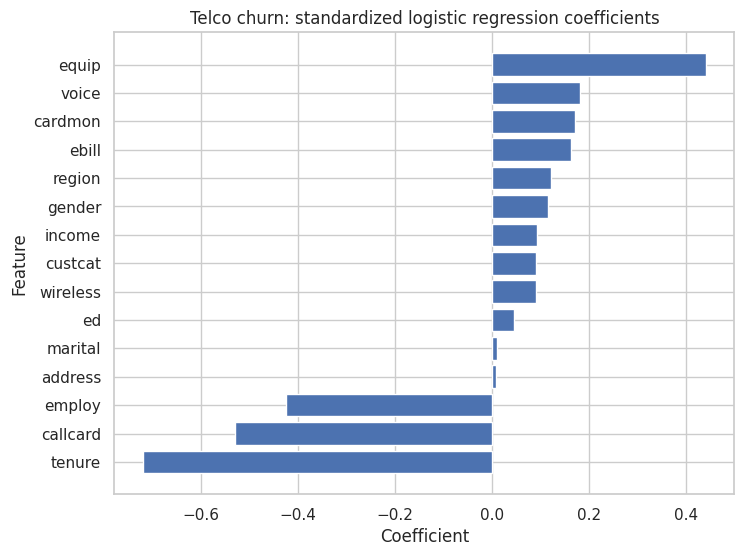

In [35]:
plt.figure(figsize=(8, 6))
telco_coef_plot = telco_coef.sort_values("coefficient")
plt.barh(telco_coef_plot["feature"], telco_coef_plot["coefficient"])
plt.title("Telco churn: standardized logistic regression coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

## 10.6 Final scoring of the provided telco test file

The provided test file has no churn label, so it cannot be used for evaluation. It can be scored to estimate churn probabilities and create a prioritized action list.

In [36]:
telco_test_scored = telco_test.copy()
telco_test_scored["churn_probability"] = telco_logreg_balanced.predict_proba(telco_test)[:, 1]
telco_test_scored["churn_flag_threshold_040"] = predict_with_threshold(telco_test_scored["churn_probability"], churn_threshold)

telco_test_scored.sort_values("churn_probability", ascending=False)

,address,callcard,cardmon,custcat,ebill,ed,employ,equip,gender,income,marital,region,tenure,voice,wireless,churn_probability,churn_flag_threshold_040
1,24,0,15.250,1,1,1,8,1,0,125,0,NaN,11,1,1,0.901,1
0,7,0,7.500,4,0,4,10,0,1,58,1,NaN,10,0,1,0.723,1
3,12,0,0.000,3,0,2,0,0,1,21,0,3.000,33,0,0,0.577,1
2,9,1,30.250,1,1,2,15,1,0,145,1,2.000,65,1,0,0.272,0


# 11. Bank marketing example

This second uploaded dataset is a small bank-marketing style classification problem. The target `y` indicates whether the customer responded positively. The CSV version may already be clean, but the workflow still checks for empty rows because spreadsheet exports sometimes create blank lines.

In [30]:
bank_path = DATA_DIR / "bank.csv"
if not bank_path.exists():
    raise FileNotFoundError("Expected bank.csv in /mnt/data")

# Read the file defensively: blank lines are ignored by default, but we still check after loading.
bank = pd.read_csv(bank_path, skip_blank_lines=True)

print("Initial shape:", bank.shape)
bank.head()

Initial shape: (41188, 6)


,Unnamed: 0,job,education,housing,loan,y
0,0,yes,no,yes,no,0
1,1,yes,yes,no,no,0
2,2,yes,yes,yes,no,1
3,3,yes,no,no,no,0
4,4,no,no,yes,no,1


In [31]:
# Remove fully empty rows if they exist.
empty_rows_before = bank.isna().all(axis=1).sum()
bank = bank.dropna(how="all").copy()
empty_rows_after = bank.isna().all(axis=1).sum()

print("Fully empty rows before cleaning:", empty_rows_before)
print("Fully empty rows after cleaning:", empty_rows_after)
print("Shape after empty-row cleaning:", bank.shape)

Fully empty rows before cleaning: 0
Fully empty rows after cleaning: 0
Shape after empty-row cleaning: (41188, 6)


In [32]:
# Drop index-like columns that do not represent business information.
index_like_cols = [col for col in bank.columns if col.lower().startswith("unnamed")]
print("Index-like columns to drop:", index_like_cols)

bank_clean = bank.drop(columns=index_like_cols)
bank_clean.head()

Index-like columns to drop: ['Unnamed: 0']


,job,education,housing,loan,y
0,yes,no,yes,no,0
1,yes,yes,no,no,0
2,yes,yes,yes,no,1
3,yes,no,no,no,0
4,no,no,yes,no,1


In [33]:
# Basic checks
print("Duplicate rows:", bank_clean.duplicated().sum())
display(summarize_missing_values(bank_clean))
display(bank_clean.describe(include="all").T)

Duplicate rows: 41156


,missing_count,missing_percent
job,0,0.000
education,0,0.000
housing,0,0.000
loan,0,0.000
y,0,0.000


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job,41188,2,yes,34372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,2,no,22046,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,2,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,2,no,34940,NaN,NaN,NaN,NaN,NaN,NaN,NaN
y,"41,188.000",NaN,NaN,NaN,0.113,0.316,0.000,0.000,0.000,0.000,1.000


In [34]:
# Target distribution
bank_clean["y"].value_counts(normalize=True).rename("share").to_frame().assign(
    count=bank_clean["y"].value_counts()
)

,share,count
y,,
0,0.887,36548
1,0.113,4640


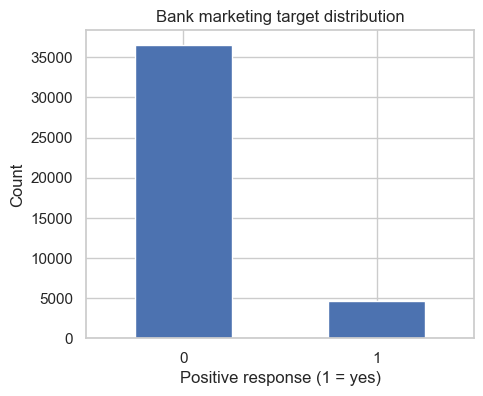

In [35]:
plt.figure(figsize=(5, 4))
bank_clean["y"].value_counts().sort_index().plot(kind="bar")
plt.title("Bank marketing target distribution")
plt.xlabel("Positive response (1 = yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 11.1 Categorical preprocessing and logistic regression

This dataset contains categorical features. Logistic regression requires numeric inputs, so categorical variables are one-hot encoded. Unknown categories in future data are ignored safely.

In [36]:
X_bank = bank_clean.drop(columns="y")
y_bank = bank_clean["y"].astype(int)

X_bank_train, X_bank_test, y_bank_train, y_bank_test = train_test_split(
    X_bank, y_bank,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_bank
)

categorical_features = X_bank_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features_bank = X_bank_train.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features_bank)

Categorical features: ['job', 'education', 'housing', 'loan']
Numeric features: []


In [38]:
categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_preprocess_bank = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

bank_preprocess = ColumnTransformer(transformers=[
    ("cat", categorical_preprocess, categorical_features),
    ("num", numeric_preprocess_bank, numeric_features_bank),
])

bank_logreg = Pipeline(steps=[
    ("preprocess", bank_preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

bank_logreg.fit(X_bank_train, y_bank_train)

bank_proba = bank_logreg.predict_proba(X_bank_test)[:, 1]
bank_pred = predict_with_threshold(bank_proba, threshold=0.5)

evaluate_binary_classifier(y_bank_test, bank_pred, bank_proba, label="Bank marketing logistic regression")

,model,accuracy,precision,recall,f1,roc_auc
0,Bank marketing logistic regression,0.490,0.138,0.670,0.228,0.589


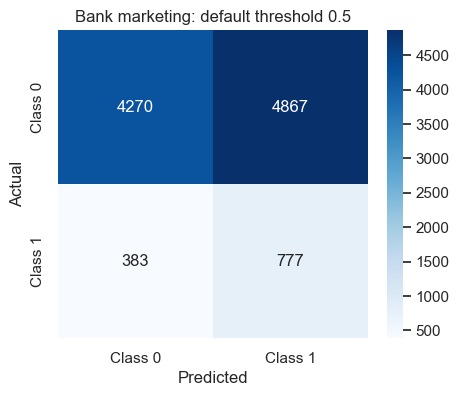

                   precision    recall  f1-score   support

      no response       0.92      0.47      0.62      9137
positive response       0.14      0.67      0.23      1160

         accuracy                           0.49     10297
        macro avg       0.53      0.57      0.42     10297
     weighted avg       0.83      0.49      0.58     10297



In [39]:
plot_confusion_matrix(y_bank_test, bank_pred, "Bank marketing: default threshold 0.5")
print(classification_report(y_bank_test, bank_pred, target_names=["no response", "positive response"]))

In [40]:
# Coefficients after one-hot encoding
encoded_feature_names = bank_logreg.named_steps["preprocess"].get_feature_names_out()
bank_coef = pd.DataFrame({
    "feature": encoded_feature_names,
    "coefficient": bank_logreg.named_steps["model"].coef_[0]
})
bank_coef["abs_coefficient"] = bank_coef["coefficient"].abs()
bank_coef.sort_values("abs_coefficient", ascending=False).head(15)

,feature,coefficient,abs_coefficient
0,cat__job_no,0.343,0.343
1,cat__job_yes,-0.284,0.284
3,cat__education_yes,0.206,0.206
2,cat__education_no,-0.147,0.147
5,cat__housing_yes,0.045,0.045
6,cat__loan_no,0.043,0.043
7,cat__loan_yes,0.016,0.016
4,cat__housing_no,0.014,0.014


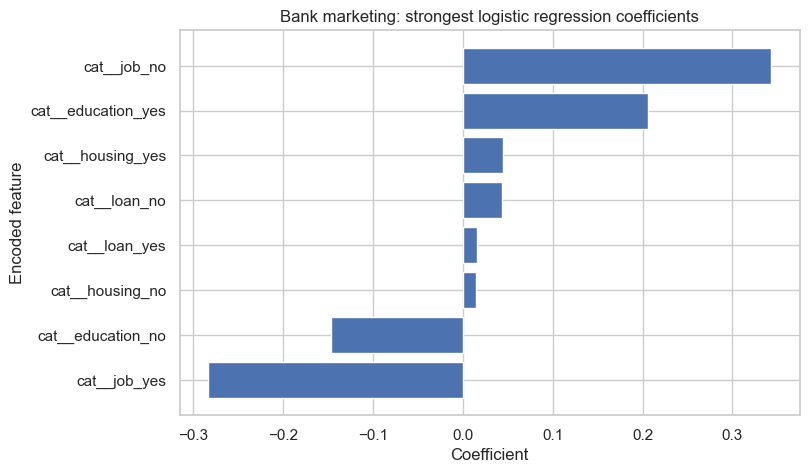

In [41]:
plt.figure(figsize=(8, 5))
top_bank_coef = bank_coef.sort_values("abs_coefficient", ascending=False).head(10).sort_values("coefficient")
plt.barh(top_bank_coef["feature"], top_bank_coef["coefficient"])
plt.title("Bank marketing: strongest logistic regression coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Encoded feature")
plt.show()

**Interpretation.** In a one-hot encoded model, each coefficient compares one category against the omitted baseline created by the encoding. Coefficients are useful for interpretation, but business meaning should be checked before drawing strong conclusions.

# 13. Common mistakes and practical pitfalls

- **Using accuracy alone.** Accuracy can look good when the positive class is rare.
- **Confusing probabilities with decisions.** A probability becomes a class only after applying a threshold.
- **Forgetting to define the positive class.** The interpretation of recall, precision, and coefficients depends on what class is coded as 1.
- **Tuning the threshold on the test set.** Use validation data for threshold choices, then report final performance on unseen test data.
- **Skipping preprocessing.** Missing values, categorical variables, scaling, and duplicate checks should be handled systematically.
- **Over-interpreting coefficients.** Coefficients support interpretation, but they are not automatically causal explanations.
- **Forcing logistic regression on highly nonlinear problems.** It is a strong baseline, but nonlinear models may perform better in future modeling topics.